# Linear least squares regression - Pseudoinverse

Let's return to linear systems again. 

Given a matrix system,

$$ 
A x = b 
$$

where $A$ is an $m\times n$ matrix, $x$ is $n$, and $b$ is $m$. We cannot solve this for an exact $x$ with our normal techniques since $A$ is rectangular, not square.

Recalling the residual is $\vec{r} = A\vec{x}-\vec{b}$, let's broaden our concept to a 'solution' to say we want to minimize the (norm of the) residual:


$$Min_x \ of \ \| \vec{r}\|=\sqrt{[Ax-b]^T [Ax-b]}$$

This is equivilant to finding the minimum of the surface: 

$$
f(\vec{x}) = \frac{1}{2} [Ax-b]^T [Ax-b]
$$

Setting $\frac{df}{d\vec{x}} = \vec{0}$, we get:

\begin{align}
A^T [Ax-b] &= 0 \\
A^T A x &= A^T b \\
 x &= [A^T A]^{-1} A^T b \\
x &= A^† b
\end{align}

where $A^†=[A^T A]^{-1} A^T$ is called the *(Moore-Penrose) pseudoinverse* of $A$. The pseudoinverse is defined for any rectangular matrix. Note $A^T A$ is necessarily square, and is generally invertible.


Terminology
* A **consistent** system of equations has a solution that satisfies *all* the equations.
* An **inconsistent** system has no solution that satisfies all equations simultaneously.

* * **Overdetermined** systems have more equations that unknowns which is typical of curve fitting. These systems are inconsistent in that there is *no simultaneous solution*, but a solution does exists that *simultaneously minimizes the error*.  
* * **Underdetermined** systems have fewer equations than unknowns and are also inconsistent but with an *infinite* number of solutions. E.g.: Parallel lines / 2 equations with 3 variables.

Some properties of the pseudoinverse:
* The pseudoinverse is defined for any rectangular matrix
* For overconstrained systems using it to solve $Ax=b$ it results in the *best fit* (in the least squares sense)
* For underconstrained systems it results in a parameterized solution. 
* The pseudoinverse also covers indefiniate matricies (linearly dependent rows)
* Since the ultimate *minimum* is $0$, the pseudoinverse is the true inverse for an exactly solvable system.

For these reasons, the pseudoinverse is commonly used to generalize the inverse in analytic derivations (e.g.: to singular matricies), however its application is subtle and the nullspace of the matrix must be considered. 

## Conditioning of a rectangular matrix

The pseudoinverse can easily be used to extend the condition number definition to rectangular matricies. 

$$
cond(A) = \|A\| \|A^\dagger\|
$$

#### Example: An overdetermined, consistent linear system

$20 c + 50 t = 700$

$  c+t = 20$

$ 50 c + 20 t = 700$

which gives the linear system:

$$\begin{bmatrix}
 20 & 50  \\
 1 & 1 \\
 50 & 20
 \end{bmatrix}
 \begin{bmatrix}
 c \\
 t
 \end{bmatrix} =
 \begin{bmatrix}
 700 \\
 20 \\
 700
 \end{bmatrix}
 $$

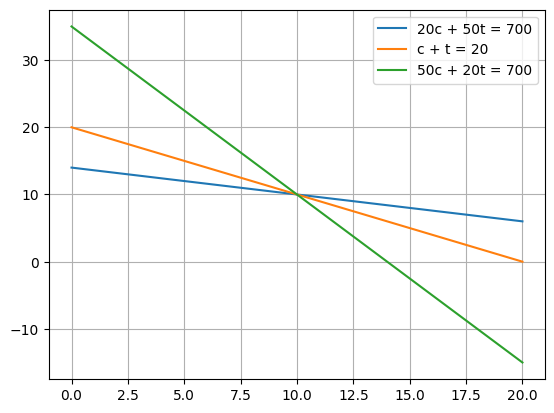

In [4]:
#Plot it!

import matplotlib.pyplot as plt
import numpy as np

# Define the x values
x = np.linspace(0, 20, 100)

# Calculate the y values for the first equation (20c + 50t = 700)
y1 = (700 - 20 * x) / 50

# Calculate the y values for the second equation (c + t = 20)
y2 = 20 - x

# Calculate the y values for the third equation (50c + 20t = 700)
y3 = (700 - 50 * x) / 20

# Plot the lines
plt.plot(x, y1, label='20c + 50t = 700')
plt.plot(x, y2, label='c + t = 20')
plt.plot(x, y3, label='50c + 20t = 700')

# Add a grid
plt.grid(True)
plt.legend()
plt.show()



In [2]:
#The arrays are:
# ~~ Question - what is the linear system and how do we solve it?

A = np.array([[20, 50], [1, 1], [50, 20]])
b = np.array([700, 20, 700])

x = np.linalg.solve(A, b)

# Breaks!



LinAlgError: Last 2 dimensions of the array must be square

This doesn't work since hte matrix is rectangular. But now let's use the pseudoinverse:

In [5]:
A = np.array([[20, 50], [1, 1], [50, 20]])
b = np.array([700, 20, 700])

M = np.linalg.inv(A.T @ A)@A.T
print('Manual calculation', M, '\n')
print('Package implementation ', np.linalg.pinv(A), '\n')
print('Residual check', M-np.linalg.pinv(A), '\n')
print('Best fit solution', M@b)


Manual calculation [[-0.00952672  0.000204    0.02380661]
 [ 0.02380661  0.000204   -0.00952672]] 

Package implementation  [[-0.00952672  0.000204    0.02380661]
 [ 0.02380661  0.000204   -0.00952672]] 

Residual check [[-1.73472348e-18  2.71050543e-19  6.93889390e-18]
 [ 1.04083409e-17 -3.25260652e-19 -1.73472348e-18]] 

Best fit solution [10. 10.]


#### Example: An overdetermined, inconsistent linear system


$2 c + t = 15$

$  c + t = 10$

$ c + 2 t = 14$

[5.36363636 4.36363636]
[5.36363636 4.36363636]


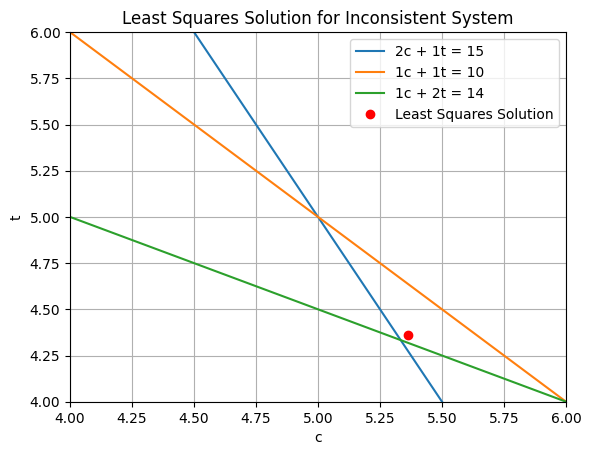

In [17]:
A = np.array([[2, 1], [1, 1], [1, 2]])
b = np.array([15, 10, 14])

x_lsq = np.linalg.pinv(A)@b
print(x_lsq)
x_lsq,_,_,_ = np.linalg.lstsq(A,b)
print(x_lsq)

# Calculate the y values for the first equation (2c + 1t = 15)
y1 = (15 - 2 * x) / 1

# Calculate the y values for the second equation (1c + 1t = 10)
y2 = 10 - x

# Calculate the y values for the third equation (1c + 2t = 14)
y3 = (14 - 1 * x) / 2

# Plot the lines
plt.plot(x, y1, label='2c + 1t = 15')
plt.plot(x, y2, label='1c + 1t = 10')
plt.plot(x, y3, label='1c + 2t = 14')

plt.plot(x_lsq[0], x_lsq[1], 'ro', label='Least Squares Solution')
plt.xlabel('c')
plt.ylabel('t')
plt.title('Least Squares Solution for Inconsistent System')
plt.legend()
plt.grid(True)
plt.xlim(4, 6)
plt.ylim(4, 6)
plt.show()

The solution found minimizes the perpendicular distance from each line. 

#### Example: An overdetermined, inconsistent linear system


$20 c + 50 t = 700$

$  c+t = 20$

$ 60 c + 20 t = 700$

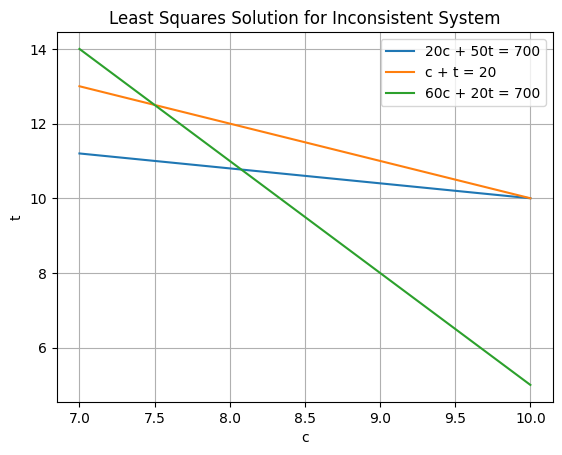

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define the x values
x = np.linspace(7, 10, 100)

# Calculate the y values for the first equation (20c + 50t = 700)
y1 = (700 - 20 * x) / 50

# Calculate the y values for the second equation (c + t = 20)
y2 = 20 - x

# Calculate the y values for the third equation (60c + 20t = 700)
y3 = (700 - 60 * x) / 20

# Plot the lines
plt.plot(x, y1, label='20c + 50t = 700')
plt.plot(x, y2, label='c + t = 20')
plt.plot(x, y3, label='60c + 20t = 700')

plt.xlabel('c')
plt.ylabel('t')
plt.title('Least Squares Solution for Inconsistent System')
plt.legend()
plt.grid(True)
plt.show()

Where do you think he solution is going to be?

[ 8.07704251 10.76953789]
[ 8.07704251 10.76953789]


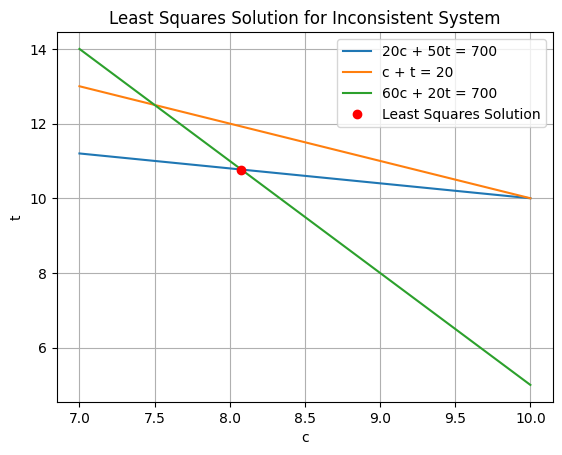

In [19]:
A = np.array([[20, 50], [1, 1], [60, 20]])
b = np.array([700, 20, 700])

#np.linalg.(A, b)
x_lsq = np.linalg.pinv(A)@b
print(x_lsq)
x_lsq,_,_,_ = np.linalg.lstsq(A,b)
print(x_lsq)

# Plot the lines
plt.plot(x, y1, label='20c + 50t = 700')
plt.plot(x, y2, label='c + t = 20')
plt.plot(x, y3, label='60c + 20t = 700')


plt.plot(x_lsq[0], x_lsq[1], 'ro', label='Least Squares Solution')
plt.xlabel('c')
plt.ylabel('t')
plt.title('Least Squares Solution for Inconsistent System')
plt.legend()
plt.grid(True)
plt.show()

Was this what you were expecting?